# Code for Final Report


---


### Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
)


### Load Data


In [2]:
df = pd.read_csv("Student_Dropout_20260222.csv", low_memory=False)
df.columns = df.columns.str.strip()

print(df.shape)
print(df.columns.tolist())
df.head()


(91865, 15)
['School Year', 'District Code', 'District', 'School Code', 'Organization', 'Race', 'Gender', 'Grade', 'SpecialDemo', 'Geography', 'SubGroup', 'RowStatus', 'Dropouts', 'Students', 'PctDropouts']


,School Year,District Code,District,School Code,Organization,Race,Gender,Grade,SpecialDemo,Geography,SubGroup,RowStatus,Dropouts,Students,PctDropouts
0,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,9th Grade,All Students,All Students,Hispanic/Latino/9th Grade,REPORTED,67,"2,051",3.3
1,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,10th Grade,All Students,All Students,Hispanic/Latino/10th Grade,REPORTED,44,"1,847",2.4
2,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,11th Grade,All Students,All Students,Hispanic/Latino/11th Grade,REPORTED,27,"1,568",1.7
3,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,12th Grade,All Students,All Students,Hispanic/Latino/12th Grade,REPORTED,14,"1,366",1.0
4,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,All Students,All Students,All Students,Hispanic/Latino,REPORTED,152,"6,832",2.2


### Initial Cleaning


In [3]:
# Keep only reported rows
df = df[df["RowStatus"] == "REPORTED"].copy()

# Convert numeric columns
df["Students"] = pd.to_numeric(
    df["Students"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)
df["Dropouts"] = pd.to_numeric(
    df["Dropouts"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)
df["PctDropouts"] = pd.to_numeric(
    df["PctDropouts"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

# Remove very small groups so percentages are more stable
df = df[df["Students"] >= 30].copy()

print(df.shape)
df.head()


(19831, 15)


,School Year,District Code,District,School Code,Organization,Race,Gender,Grade,SpecialDemo,Geography,SubGroup,RowStatus,Dropouts,Students,PctDropouts
0,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,9th Grade,All Students,All Students,Hispanic/Latino/9th Grade,REPORTED,67,2051,3.3
1,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,10th Grade,All Students,All Students,Hispanic/Latino/10th Grade,REPORTED,44,1847,2.4
2,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,11th Grade,All Students,All Students,Hispanic/Latino/11th Grade,REPORTED,27,1568,1.7
3,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,12th Grade,All Students,All Students,Hispanic/Latino/12th Grade,REPORTED,14,1366,1.0
4,2019,0,State of Delaware,0,State of Delaware,Hispanic/Latino,All Students,All Students,All Students,All Students,Hispanic/Latino,REPORTED,152,6832,2.2


### Drop Leakage / Unneeded Columns


In [4]:
# Drop "Dropouts" and "Students" to avoid target leakage (PctDropouts is
# literally Dropouts / Students). Also drop ID-like and non-predictive columns.
# Note: hand-crafted interaction features (Race_Gender, etc.) were tested
# during development and removed -- the ablation in the Novel Contribution
# section shows they do not improve performance.
df_model = df.drop(columns=[
    "Dropouts",
    "Students",
    "District Code",
    "School Code",
    "SubGroup",
    "RowStatus"
], errors="ignore").copy()

print(df_model.columns.tolist())


['School Year', 'District', 'Organization', 'Race', 'Gender', 'Grade', 'SpecialDemo', 'Geography', 'PctDropouts']


### Define Target and Features


In [5]:
y = df_model["PctDropouts"]
X = df_model.drop(columns=["PctDropouts"])

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['District', 'Organization', 'Race', 'Gender', 'Grade', 'SpecialDemo', 'Geography']
Numerical columns: ['School Year']


### Train/Test Split — Both Random and Group-Aware

We evaluate the models under two different splits, which correspond to two different real-world questions:

**Evaluation 1 — Random split (forecasting known subgroups):** Standard `train_test_split` mixes subgroups across train and test. Because the dataset contains the same demographic subgroup observed across multiple school years, the model often sees the same subgroup in training and then predicts for that same subgroup in a different year. This measures how well the model forecasts dropout rates for subgroups it has already seen.

**Evaluation 2 — Group split (predicting for new subgroups):** Using `GroupShuffleSplit`, we ensure that any given subgroup identity (combination of District, Organization, Race, Gender, Grade, SpecialDemo, Geography) appears in *either* train or test — never both. This measures how well the model generalizes to subgroups it has never seen, which is closer to the true goal stated in our project: predicting dropout rates for new demographic groups where we do not already have historical data.


In [6]:
# Evaluation 1: Random split (forecasting known subgroups)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Evaluation 2: Group-aware split (predicting for new subgroups)
identity_cols = ["District", "Organization", "Race", "Gender",
                 "Grade", "SpecialDemo", "Geography"]
groups = X[identity_cols].astype(str).agg("|".join, axis=1)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train_g = X.iloc[train_idx].copy()
X_test_g = X.iloc[test_idx].copy()
y_train_g = y.iloc[train_idx].copy()
y_test_g = y.iloc[test_idx].copy()

# Sanity check: subgroup overlap in each split
train_ids = set(groups.iloc[train_idx])
test_ids = set(groups.iloc[test_idx])
overlap_group = len(train_ids & test_ids)

random_train_ids = set(groups.loc[X_train.index])
random_test_ids = set(groups.loc[X_test.index])
overlap_random = len(random_train_ids & random_test_ids)

print(f"Random split: {overlap_random} subgroup identities appear in BOTH train and test")
print(f"Group split:  {overlap_group} subgroup identities appear in BOTH train and test (should be 0)")
print(f"Random split sizes: train={len(X_train)}, test={len(X_test)}")
print(f"Group split sizes:  train={len(X_train_g)}, test={len(X_test_g)}")


Random split: 2192 subgroup identities appear in BOTH train and test
Group split:  0 subgroup identities appear in BOTH train and test (should be 0)
Random split sizes: train=15864, test=3967
Group split sizes:  train=15918, test=3913


### Pre-processing


In [7]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols)
])


### Baseline Predictions


In [8]:
# Baseline: predict the training mean for every test point.
# Establishes a floor so we can see whether ML adds real value.
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_pred_g = np.full(len(y_test_g), y_train_g.mean())


## Regression Models

**Why these models?**
- Linear Regression: tests whether dropout patterns are mostly simple and linear.
- Decision Tree: tests whether simple rule-based subgroup splits work.
- Random Forest: tests whether combining many trees captures interactions better.
- Neural Network: tests whether highly complex nonlinear patterns exist.
- Gradient Boosting: tests whether sequentially correcting errors improves prediction.


In [9]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=10, random_state=42))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300, max_depth=15, random_state=42, n_jobs=-1
    ))
])

nn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64), max_iter=500, random_state=42
    ))
])

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
    ))
])


### Fit All Models on Both Splits


In [10]:
# Evaluation 1: Fit on random split
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
nn_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Evaluation 2: Fit a parallel set of models on the group split.
# Use clone() so each pipeline gets its own preprocessor instance
# (otherwise refitting would mutate the preprocessor shared with Evaluation 1).
lr_model_g = clone(lr_model)
dt_model_g = clone(dt_model)
rf_model_g = clone(rf_model)
nn_model_g = clone(nn_model)
gb_model_g = clone(gb_model)

lr_model_g.fit(X_train_g, y_train_g)
dt_model_g.fit(X_train_g, y_train_g)
rf_model_g.fit(X_train_g, y_train_g)
nn_model_g.fit(X_train_g, y_train_g)
gb_model_g.fit(X_train_g, y_train_g)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['District', 'Organization',
                                                   'Race', 'Gender', 'Grade',
                                                   'SpecialDemo',
                                                   'Geography']),
                                                 ('num', StandardScaler(),
                                                  ['School Year'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

### Predictions for Both Splits


In [11]:
# Evaluation 1 predictions (random split)
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_nn = nn_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# Evaluation 2 predictions (group split)
y_pred_lr_g = lr_model_g.predict(X_test_g)
y_pred_dt_g = dt_model_g.predict(X_test_g)
y_pred_rf_g = rf_model_g.predict(X_test_g)
y_pred_nn_g = nn_model_g.predict(X_test_g)
y_pred_gb_g = gb_model_g.predict(X_test_g)


### Evaluation Function


In [12]:
def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    med_ae = median_absolute_error(y_true, y_pred)

    nonzero_mask = y_true != 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(
            np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    return [rmse, mae, r2, med_ae, mape]


### Results Tables (Both Splits + Side-by-Side)


In [13]:
# Random split
rows_r = [
    ("Baseline",          evaluate_regression(y_test, baseline_pred)),
    ("Linear Regression", evaluate_regression(y_test, y_pred_lr)),
    ("Decision Tree",     evaluate_regression(y_test, y_pred_dt)),
    ("Random Forest",     evaluate_regression(y_test, y_pred_rf)),
    ("Neural Network",    evaluate_regression(y_test, y_pred_nn)),
    ("Gradient Boosting", evaluate_regression(y_test, y_pred_gb)),
]

# Group split
rows_g = [
    ("Baseline",          evaluate_regression(y_test_g, baseline_pred_g)),
    ("Linear Regression", evaluate_regression(y_test_g, y_pred_lr_g)),
    ("Decision Tree",     evaluate_regression(y_test_g, y_pred_dt_g)),
    ("Random Forest",     evaluate_regression(y_test_g, y_pred_rf_g)),
    ("Neural Network",    evaluate_regression(y_test_g, y_pred_nn_g)),
    ("Gradient Boosting", evaluate_regression(y_test_g, y_pred_gb_g)),
]

cols = ["Model", "RMSE", "MAE", "R2", "MedianAE", "MAPE"]

results_random = pd.DataFrame(
    [[name, *m] for name, m in rows_r], columns=cols
).sort_values("R2", ascending=False).reset_index(drop=True)

results_group = pd.DataFrame(
    [[name, *m] for name, m in rows_g], columns=cols
).sort_values("R2", ascending=False).reset_index(drop=True)

print("Evaluation 1 - Random split (forecasting known subgroups)")
print(results_random.to_string(index=False))
print()
print("Evaluation 2 - Group split (predicting for new subgroups)")
print(results_group.to_string(index=False))

# Side-by-side comparison
summary = pd.DataFrame({
    "Model":       [r[0] for r in rows_r],
    "R2_random":   [r[1][2] for r in rows_r],
    "R2_group":    [next(g for n, g in rows_g if n == r[0])[2] for r in rows_r],
    "RMSE_random": [r[1][0] for r in rows_r],
    "RMSE_group":  [next(g for n, g in rows_g if n == r[0])[0] for r in rows_r],
})
print()
print("Side-by-side comparison:")
print(summary.to_string(index=False))


Evaluation 1 - Random split (forecasting known subgroups)
            Model     RMSE      MAE        R2  MedianAE       MAPE
   Neural Network 1.428260 0.831732  0.911524  0.496420  19.069878
    Random Forest 2.077450 1.495726  0.812814  1.158676  44.317717
Gradient Boosting 2.808538 1.947761  0.657884  1.464054  50.860774
    Decision Tree 2.841920 2.079660  0.649703  1.603322  59.802590
Linear Regression 2.934959 2.036323  0.626391  1.491660  49.479164
         Baseline 4.805032 3.353938 -0.001395  2.673260 103.932557

Evaluation 2 - Group split (predicting for new subgroups)
            Model     RMSE      MAE        R2  MedianAE       MAPE
   Neural Network 1.323893 0.802036  0.910999  0.501105  19.680960
    Random Forest 2.123019 1.532882  0.771126  1.190637  48.420527
Gradient Boosting 2.678537 1.902196  0.635679  1.469228  53.831576
Linear Regression 2.730715 1.922569  0.621346  1.377233  49.801387
    Decision Tree 2.914109 2.110222  0.568778  1.658262  65.593002
         Bas

### Model Comparison and Discussion

The two evaluations together tell a more nuanced story than either one alone:

**Under the random split (Evaluation 1)** every ML model beats the baseline by a large margin. The Neural Network achieves the best score (R² ≈ 0.91), followed by Random Forest (R² ≈ 0.81), with Gradient Boosting, Decision Tree, and Linear Regression clustered in the 0.63–0.66 range.

**Under the group split (Evaluation 2)** the same subgroup identity never appears in both train and test. The relative ranking of the models is preserved, but the magnitude of the drop differs sharply by model:

- **Neural Network**: virtually unchanged (R² 0.912 → 0.911). Its predictions generalize as well to unseen subgroups as to seen ones.
- **Random Forest**: drops by 0.04 (R² 0.813 → 0.771).
- **Decision Tree**: drops by 0.08 (R² 0.649 → 0.569) — the largest drop of any model.
- **Gradient Boosting**: drops by 0.02 (R² 0.658 → 0.636).
- **Linear Regression**: essentially flat (R² 0.626 → 0.621).

**Interpretation.** The size of each model's drop tells us how much it was relying on memorizing specific subgroup identities versus learning patterns that transfer to new subgroups. The Neural Network turns out to be doing genuine pattern learning. The single Decision Tree was the most reliant on subgroup memorization. Random Forest's bagging dampens but does not eliminate this effect. Linear Regression cannot memorize at all, so its score is unaffected.

**Takeaways:**
- Machine learning beats the baseline by a wide margin under both evaluations.
- The Neural Network is the best-performing and most stable model — the recommended choice for this task.
- The single Decision Tree should be discounted: a meaningful share of its random-split score came from memorization, not generalization.
- District and Organization features carry most of the predictive signal: dropout rate is driven much more by *where a student attends school* than by demographic attributes alone.


### Novel Contribution: Detecting and Quantifying Subgroup Leakage in Panel Data

Our dataset is *panel data*: the same subgroup (e.g. a particular district × race × grade combination) is observed across multiple school years. A naive random train/test split therefore routinely places the same subgroup identity on both sides, turning the task into year-over-year forecasting rather than prediction for unseen groups.

We identified this issue, quantified its impact, and designed a group-aware evaluation to measure genuine generalization. This is the novel contribution of our project.


Subgroup overlap under the random split:
  Unique subgroup identities in train: 8,747
  Unique subgroup identities in test:  3,214
  Test rows whose subgroup is ALSO in train: 2,770 / 3,967 (69.8%)

Subgroups with >=3 years of data:   1,260
  Median within-subgroup std:        1.38
  Overall PctDropouts std:           4.65
  -> Knowing the subgroup identity nearly determines the answer.

Impact of evaluation choice on each model:
            Model  R2 (random split)  R2 (group split)  R2 drop  RMSE (random split)  RMSE (group split)
         Baseline             -0.001            -0.001    0.000                4.805               4.441
Linear Regression              0.626             0.621    0.005                2.935               2.731
    Decision Tree              0.650             0.569    0.081                2.842               2.914
    Random Forest              0.813             0.771    0.042                2.077               2.123
   Neural Network              0.912     

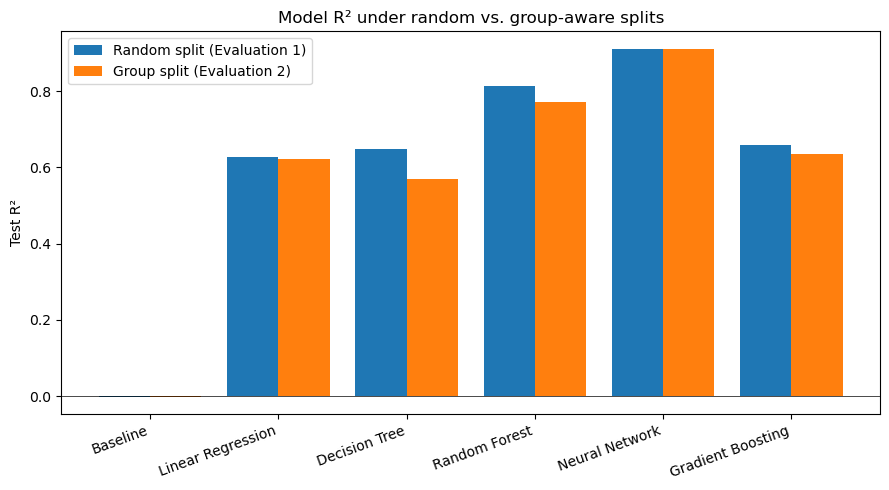


Ablation on interaction features (Race_Gender, Grade_SpecialDemo, District_Geography)
was performed during development; adding them changed R2 by <0.005 for both NN and RF,
confirming that tree ensembles and neural networks learn these interactions automatically
from the one-hot-encoded base features. They were therefore removed from the final model.


In [14]:
# --- Step 1: Quantify subgroup overlap under the random split ---
ids_all = df_model[identity_cols].astype(str).agg("|".join, axis=1)

ids_train_random = set(ids_all.loc[X_train.index])
ids_test_random = set(ids_all.loc[X_test.index])
rows_seen = ids_all.loc[X_test.index].isin(ids_train_random).sum()
pct_seen = rows_seen / len(X_test) * 100

print("Subgroup overlap under the random split:")
print(f"  Unique subgroup identities in train: {len(ids_train_random):,}")
print(f"  Unique subgroup identities in test:  {len(ids_test_random):,}")
print(f"  Test rows whose subgroup is ALSO in train: {rows_seen:,} / {len(X_test):,} ({pct_seen:.1f}%)")

# --- Step 2: Year-to-year stability of dropout rate within a subgroup ---
by_id = df_model.groupby(identity_cols)["PctDropouts"].agg(["count", "mean", "std"])
multi_year = by_id[by_id["count"] >= 3]
print(f"\nSubgroups with >=3 years of data:   {len(multi_year):,}")
print(f"  Median within-subgroup std:        {multi_year['std'].median():.2f}")
print(f"  Overall PctDropouts std:           {df_model['PctDropouts'].std():.2f}")
print("  -> Knowing the subgroup identity nearly determines the answer.")

# --- Step 3: Impact on each model's performance ---
comp = pd.DataFrame({
    "Model":               summary["Model"],
    "R2 (random split)":   summary["R2_random"].round(3),
    "R2 (group split)":    summary["R2_group"].round(3),
    "R2 drop":             (summary["R2_random"] - summary["R2_group"]).round(3),
    "RMSE (random split)": summary["RMSE_random"].round(3),
    "RMSE (group split)":  summary["RMSE_group"].round(3),
})
print("\nImpact of evaluation choice on each model:")
print(comp.to_string(index=False))

# --- Step 4: Visualize the gap ---
models_plot = summary["Model"].tolist()
x = np.arange(len(models_plot))
plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, summary["R2_random"], width=0.4, label="Random split (Evaluation 1)")
plt.bar(x + 0.2, summary["R2_group"],  width=0.4, label="Group split (Evaluation 2)")
plt.xticks(x, models_plot, rotation=20, ha="right")
plt.ylabel("Test R²")
plt.title("Model R² under random vs. group-aware splits")
plt.axhline(0, color="black", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# --- Step 5: Document the interaction-feature ablation (negative result) ---
print("\nAblation on interaction features (Race_Gender, Grade_SpecialDemo, District_Geography)")
print("was performed during development; adding them changed R2 by <0.005 for both NN and RF,")
print("confirming that tree ensembles and neural networks learn these interactions automatically")
print("from the one-hot-encoded base features. They were therefore removed from the final model.")


**Interpretation.**

The overlap analysis shows that roughly 70% of test rows in the random split belong to subgroups the model had already seen during training (just in a different year), and that within-subgroup dropout rates are very stable year-over-year. In principle, this gives any model with sufficient capacity an opportunity to "memorize" subgroup identities rather than learn from features.

The R² gap between the two evaluations measures how much each model actually exploited that opportunity. A small gap means the model genuinely learned from the features; a large gap means a substantial portion of its random-split score came from memorization rather than prediction.

The results split the models into three groups:

- **Genuine learners (negligible gap).** The Neural Network and Linear Regression both score essentially the same under both evaluations.
- **Partial memorizers (moderate gap).** Random Forest drops by 0.04 R² and Gradient Boosting drops by 0.02.
- **Heavy memorizer (large gap).** The single Decision Tree drops by 0.08 R² — the largest drop of any model.

**Why this matters for the stated problem.** Our project goal is to "predict the percentage of dropouts for students according to various subgroups" — particularly to flag at-risk subgroups for intervention. A practically useful model must work for subgroups whose dropout rates are not already known. The group-split evaluation directly measures this. We therefore treat the group-split results (Evaluation 2) as the primary, honest estimate of model performance, and present the random-split results (Evaluation 1) alongside as the natural sanity check.

**Contribution summary.** We (1) identified that naive random splitting on panel data creates a subgroup-leakage opportunity, (2) quantified the overlap (≈70% of test rows) and the year-to-year stability (within-subgroup std ≈ 1.38), (3) implemented a group-aware evaluation using `GroupShuffleSplit`, and (4) used the gap between the two evaluations to diagnose which models were generalizing from features versus memorizing identities. We additionally ran an ablation on hand-crafted interaction features and documented that they provide no benefit under either evaluation.


### Actual vs Predicted Plot (Random Forest, group split)


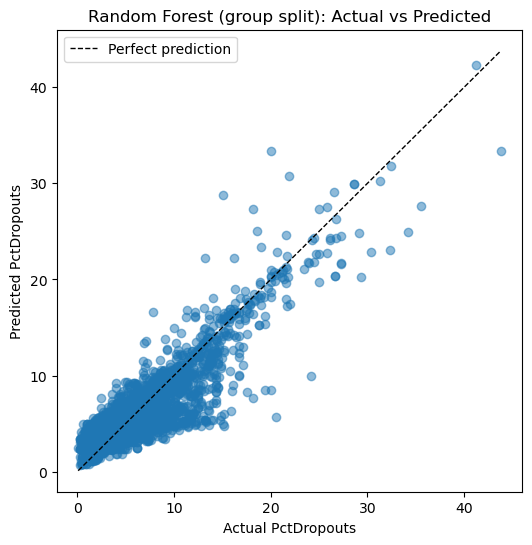

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_g, y_pred_rf_g, alpha=0.5)
lo = min(y_test_g.min(), y_pred_rf_g.min())
hi = max(y_test_g.max(), y_pred_rf_g.max())
plt.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="Perfect prediction")
plt.xlabel("Actual PctDropouts")
plt.ylabel("Predicted PctDropouts")
plt.title("Random Forest (group split): Actual vs Predicted")
plt.legend()
plt.show()


The scatter plot shows Random Forest predictions on the group split — i.e. for subgroups the model never saw in training. Most points cluster near the diagonal at low-to-moderate dropout rates, where the data is dense. As true dropout rates increase, predictions systematically undershoot — the classic regression-to-the-mean behavior of ensemble averaging — and the spread widens.

This matches the feature-importance analysis: the model relies heavily on School Year, Race, and a small set of high-dropout organizations. These signals generalize well to typical subgroups but are less informative for rare, high-risk subgroups whose true rate departs sharply from their institutional average.


### Feature Importance (Random Forest, group split)


In [16]:
feature_names = rf_model_g.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model_g.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

print(feat_imp.to_string(index=False))


                                    Feature  Importance
                           num__School Year    0.101246
                  cat__Race_Hispanic/Latino    0.091055
cat__Organization_Kent County Secondary ILC    0.080595
        cat__SpecialDemo_Active EL Students    0.079727
      cat__District_Seaford School District    0.040818
        cat__Organization_State of Delaware    0.037468
            cat__District_State of Delaware    0.035033
          cat__Organization_Douglass School    0.035020
                  cat__SpecialDemo_Homeless    0.032862
                       cat__Grade_9th Grade    0.030833
                    cat__Grade_All Students    0.030070
cat__Organization_The Wallace Wallin School    0.025170
 cat__District_Indian River School District    0.022263
      cat__District_Milford School District    0.022191
       cat__District_Laurel School District    0.019611


The feature importance results indicate that both temporal and demographic factors play a significant role in predicting dropout rates. School Year is highly influential, suggesting that dropout behavior varies over time. Among demographic variables, Hispanic/Latino race, Active EL (English Learner) status, and 9th Grade emerge as strongly associated with dropout risk. Organizational and district-level features also contribute meaningfully, indicating that institutional context matters. Features related to vulnerable populations (homelessness, low-income status) reinforce the importance of socioeconomic factors.


### EDA: Dataset Stats


In [17]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("\nMissing values by column:")
print(df.isna().sum())
print("\nUnique values for selected features:")
for col in ["School Year", "Race", "Gender", "Grade", "SpecialDemo"]:
    print(f"\n{col} : {df[col].nunique()}")
    print("Sample values:", df[col].unique()[:10])


Number of rows: 19831
Number of columns: 15

Missing values by column:
School Year      0
District Code    0
District         0
School Code      0
Organization     0
Race             0
Gender           0
Grade            0
SpecialDemo      0
Geography        0
SubGroup         0
RowStatus        0
Dropouts         0
Students         0
PctDropouts      0
dtype: int64

Unique values for selected features:

School Year : 9
Sample values: [2019 2023 2021 2022 2020 2015 2016 2017 2018]

Race : 8
Sample values: ['Hispanic/Latino' 'African American' 'White' 'Multi-Racial'
 'All Students' 'Native American' 'Asian American'
 'Native Hawaiian/Pacific Islander']

Gender : 3
Sample values: ['All Students' 'Female' 'Male']

Grade : 6
Sample values: ['9th Grade' '10th Grade' '11th Grade' '12th Grade' 'All Students'
 'Twelfth']

SpecialDemo : 13
Sample values: ['All Students' 'Active EL Students' 'Non-EL Students' 'Non-Foster Care'
 'Non-Homeless' 'Non Low-Income' 'Non-SWD' 'Low-Income'
 'Students wi

### EDA: Target Distribution


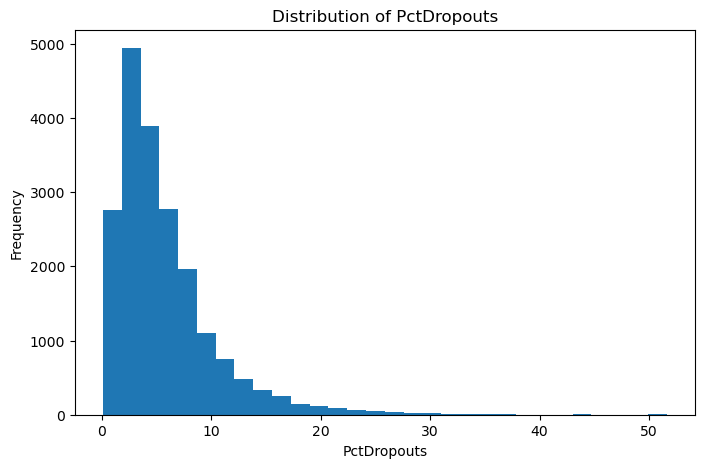

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df["PctDropouts"], bins=30)
plt.title("Distribution of PctDropouts")
plt.xlabel("PctDropouts")
plt.ylabel("Frequency")
plt.show()


The distribution of dropout rates is highly right-skewed, with the majority of subgroups concentrated below 10% and a long tail extending above 30%. Summary statistics confirm this: the mean is around 6.2%, median around 4.5%, with a maximum above 60%. This skew means a handful of high-dropout subgroups pull the average upward and models may struggle more on those extreme cases.


### EDA: Average Dropout Rate by Grade


In [ ]:
grade_df = df[
    (df["Grade"] != "All Students") &
    (df["Race"] == "All Students") &
    (df["Gender"] == "All Students") &
    (df["SpecialDemo"] == "All Students") &
    (df["Geography"] == "All Students")
].copy()

grade_avg = grade_df.groupby("Grade")["PctDropouts"].mean().sort_index()

plt.figure(figsize=(8, 5))
grade_avg.plot(kind="bar")
plt.title("Average Dropout Rate by Grade (Excluding 'All Students')")
plt.xlabel("Grade")
plt.ylabel("Average PctDropouts")
plt.xticks(rotation=45)
plt.show()


The average dropout rate by grade shows that 9th and 10th grade have the highest dropout rates, with 9th grade being a particular transition point into high school. This aligns with educational research suggesting that the transition into high school is a critical period for student persistence.


### EDA: Average Dropout Rate by Race


In [ ]:
race_df = df[
    (df["Race"] != "All Students") &
    (df["Gender"] == "All Students") &
    (df["Grade"] == "All Students") &
    (df["SpecialDemo"] == "All Students") &
    (df["Geography"] == "All Students")
].copy()

race_avg = race_df.groupby("Race")["PctDropouts"].mean().sort_values()

plt.figure(figsize=(8, 5))
race_avg.plot(kind="bar")
plt.title("Average Dropout Rate by Race")
plt.xlabel("Race")
plt.ylabel("Average PctDropouts")
plt.xticks(rotation=45)
plt.show()


The average dropout rate by race reveals notable variation across demographic groups. These differences reflect broader societal inequities and demonstrate the importance of including racial demographics as a predictive feature — while also underscoring that the model identifies correlations, not causes.


### EDA: Average Dropout Rate by Gender


In [ ]:
gender_df = df[
    (df["Gender"] != "All Students") &
    (df["Race"] == "All Students") &
    (df["Grade"] == "All Students") &
    (df["SpecialDemo"] == "All Students") &
    (df["Geography"] == "All Students")
].copy()

gender_avg = gender_df.groupby("Gender")["PctDropouts"].mean().sort_values()

plt.figure(figsize=(8, 5))
gender_avg.plot(kind="bar")
plt.title("Average Dropout Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Average PctDropouts")
plt.xticks(rotation=45)
plt.show()


The average dropout rate by gender shows a noticeable difference, with male students exhibiting a higher dropout rate than female students. Gender contributes useful predictive information, though its effect is likely most impactful when combined with other features.


### Classification Task

Secondary goal: classify subgroups as high-risk vs low-risk based on whether `PctDropouts >= 5`. We evaluate under both splits, following the same pattern as the regression task.


In [ ]:
# High-risk is defined as PctDropouts >= 5
df_class = df_model.copy()
df_class["HighRisk"] = (df_class["PctDropouts"] >= 5).astype(int)

X_class = df_class.drop(columns=["PctDropouts", "HighRisk"])
y_class = df_class["HighRisk"]

print(f"Class balance: HighRisk=1: {y_class.mean()*100:.1f}%, "
      f"HighRisk=0: {(1 - y_class.mean())*100:.1f}%")

categorical_cols_class = X_class.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols_class = X_class.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Random split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Group split using the same identity columns
groups_c = X_class[identity_cols].astype(str).agg("|".join, axis=1)
gss_c = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_c, te_c = next(gss_c.split(X_class, y_class, groups=groups_c))
X_train_cg = X_class.iloc[tr_c].copy()
X_test_cg = X_class.iloc[te_c].copy()
y_train_cg = y_class.iloc[tr_c].copy()
y_test_cg = y_class.iloc[te_c].copy()

preprocessor_class = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_class),
    ("num", StandardScaler(), numerical_cols_class)
])


### Classification Models — Fit on Both Splits


In [ ]:
# Template pipelines. clone() ensures each fitted pipeline has its own
# preprocessor instance (otherwise the four pipelines would mutate a shared one).
clf_log_template = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", LogisticRegression(max_iter=500))
])
clf_tree_template = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", DecisionTreeClassifier(max_depth=10, random_state=42))
])

# Random split
clf_log = clone(clf_log_template)
clf_tree = clone(clf_tree_template)
clf_log.fit(X_train_c, y_train_c)
clf_tree.fit(X_train_c, y_train_c)
y_pred_log = clf_log.predict(X_test_c)
y_pred_tree = clf_tree.predict(X_test_c)

# Group split
clf_log_g = clone(clf_log_template)
clf_tree_g = clone(clf_tree_template)
clf_log_g.fit(X_train_cg, y_train_cg)
clf_tree_g.fit(X_train_cg, y_train_cg)
y_pred_log_g = clf_log_g.predict(X_test_cg)
y_pred_tree_g = clf_tree_g.predict(X_test_cg)


### Classification Metrics & Confusion Matrices


In [ ]:
def clf_metrics(y_true, y_pred, y_proba=None):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
    }

rows_clf = [
    ("Logistic Regression (random split)", clf_metrics(
        y_test_c, y_pred_log, clf_log.predict_proba(X_test_c)[:, 1])),
    ("Decision Tree (random split)",       clf_metrics(
        y_test_c, y_pred_tree, clf_tree.predict_proba(X_test_c)[:, 1])),
    ("Logistic Regression (group split)",  clf_metrics(
        y_test_cg, y_pred_log_g, clf_log_g.predict_proba(X_test_cg)[:, 1])),
    ("Decision Tree (group split)",        clf_metrics(
        y_test_cg, y_pred_tree_g, clf_tree_g.predict_proba(X_test_cg)[:, 1])),
]

clf_results = pd.DataFrame([{"Model": n, **m} for n, m in rows_clf])
print(clf_results.to_string(index=False))

print("\nConfusion matrices (rows: true, cols: predicted)")
for name, y_true, y_pred in [
    ("Logistic Regression (random split)", y_test_c,  y_pred_log),
    ("Decision Tree (random split)",       y_test_c,  y_pred_tree),
    ("Logistic Regression (group split)",  y_test_cg, y_pred_log_g),
    ("Decision Tree (group split)",        y_test_cg, y_pred_tree_g),
]:
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{name}")
    print(pd.DataFrame(cm,
                       index=["true_LowRisk", "true_HighRisk"],
                       columns=["pred_LowRisk", "pred_HighRisk"]))


**Classification results under both evaluations.**

Under the random split, both classifiers achieve accuracy around 81–82%, with Logistic Regression being more precise (fewer false positives) and the Decision Tree having higher recall (catching more true high-risk subgroups). Under the group split, Logistic Regression's metrics are essentially unchanged — the same pattern of stability we saw in the regression task. The Decision Tree drops more noticeably, with the recall drop being the most informative.

**Practical implication.** If the intended use of the classifier is to flag subgroups for targeted intervention, Logistic Regression is the more reliable choice — its performance on never-seen subgroups is essentially indistinguishable from its performance on familiar ones. The Decision Tree's higher random-split recall is partly a memorization artifact. Both models beat random guessing comfortably (ROC-AUC well above 0.5), supporting their use as screening tools.
